# mini_68 planner outcomes: exploratory analysis

Descriptive EDA of the committed matched-pair outcomes for IDM and PDM-Closed on the
68 fixed `mini_68` scenarios. It reads only committed files
(`artifacts/mini_68/`, `configs/scenarios/idm_mini_sample.csv`), so it runs **without
the nuPlan dataset or Docker**.

Scope and caveats:

- This is descriptive. The 68 scenarios are a category-balanced pilot sample, not
  mini's natural distribution, and scenarios from the same log are correlated.
  Subgroup results (5 or fewer scenarios per category) are not estimates.
- Pre-simulation covariates (ego speed, agent counts, traffic lights, ...) are not
  extracted yet, so heterogeneity is explored only by category, map, log and tags.
  Tags are look-ahead labels and are used here for description, not as model inputs
  (see [the subset and required-fields document](../docs/research/nuplan_scenario_subset_and_required_fields.md)).
- No model is trained.

Figures are also written to `artifacts/eda/mini_68_outcomes/` (ignored by Git).

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "artifacts" / "mini_68").is_dir())
DATA = ROOT / "artifacts" / "mini_68"
FIG_DIR = ROOT / "artifacts" / "eda" / "mini_68_outcomes"
FIG_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.precision", 3)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 110)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})
COLORS = {"idm": "#1f77b4", "pdm-closed": "#d62728"}
PLANNERS = ["idm", "pdm-closed"]
CITY = {"us-nv-las-vegas-strip": "Las Vegas", "us-ma-boston": "Boston",
        "us-pa-pittsburgh-hazelwood": "Pittsburgh", "sg-one-north": "Singapore"}
EPS = 1e-9


def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")

## 1. Load and check the committed data

In [2]:
long = pd.read_parquet(DATA / "planner_outcomes.parquet")
manifest = pd.read_csv(ROOT / "configs" / "scenarios" / "idm_mini_sample.csv")
experiment = json.loads((DATA / "experiment.json").read_text())

long = long.merge(manifest[["scenario_id", "all_scenario_tags"]], on="scenario_id", validate="many_to_one")
long["city"] = long["map_name"].map(CITY)

assert len(long) == 136 and long["scenario_id"].nunique() == 68
assert long.groupby("scenario_id")["planner"].apply(lambda s: sorted(s) == PLANNERS).all()
assert long["succeeded"].all()
for planner, run in experiment["source_runs"].items():
    assert np.isclose(long.loc[long.planner == planner, "score"].mean(), run["official_score"])

print(f"{len(long)} rows | {long.scenario_id.nunique()} scenarios | {long.log_name.nunique()} logs | "
      f"{long.scenario_type.nunique()} categories | {long.map_name.nunique()} maps")
print("simulation:", experiment["simulation"], "| seed:", experiment["simulation_seed"])

136 rows | 68 scenarios | 38 logs | 14 categories | 4 maps
simulation: closed_loop_reactive_agents | seed: 0


### How the nuPlan score is built

The scenario score is the product of four **multiplier** metrics (any zero makes the
score zero) times a weighted average of four **weighted** metrics
(progress 5, time-to-collision 5, speed limit 4, comfort 2). Reconstructing it from
the stored components confirms the columns are complete:

In [3]:
MULTIPLIERS = ["no_ego_at_fault_collisions", "drivable_area_compliance",
               "driving_direction_compliance", "ego_is_making_progress"]
WEIGHTED = {"ego_progress_along_expert_route": 5, "time_to_collision_within_bound": 5,
            "speed_limit_compliance": 4, "ego_is_comfortable": 2}
METRICS = MULTIPLIERS + list(WEIGHTED)

multiplier = long[MULTIPLIERS].prod(axis=1)
weighted = sum(long[m] * w for m, w in WEIGHTED.items()) / sum(WEIGHTED.values())
print("max |reconstructed - score| =", float((multiplier * weighted - long["score"]).abs().max()))
long["multiplier_product"] = multiplier
long["weighted_average"] = weighted

max |reconstructed - score| = 1.1102230246251565e-16


## 2. Score distribution per planner

In [4]:
def summarize(s):
    return pd.Series({
        "mean": s.mean(), "median": s.median(), "std": s.std(),
        "share_zero": (s <= EPS).mean(), "share_perfect": (s >= 1 - EPS).mean(),
        "share_below_0.5": (s < 0.5).mean(),
    })

long.groupby("planner")["score"].apply(summarize).unstack()

,mean,median,std,share_zero,share_perfect,share_below_0.5
planner,,,,,,
idm,0.76,0.979,0.385,0.191,0.426,0.191
pdm-closed,0.90,1.000,0.247,0.059,0.574,0.074


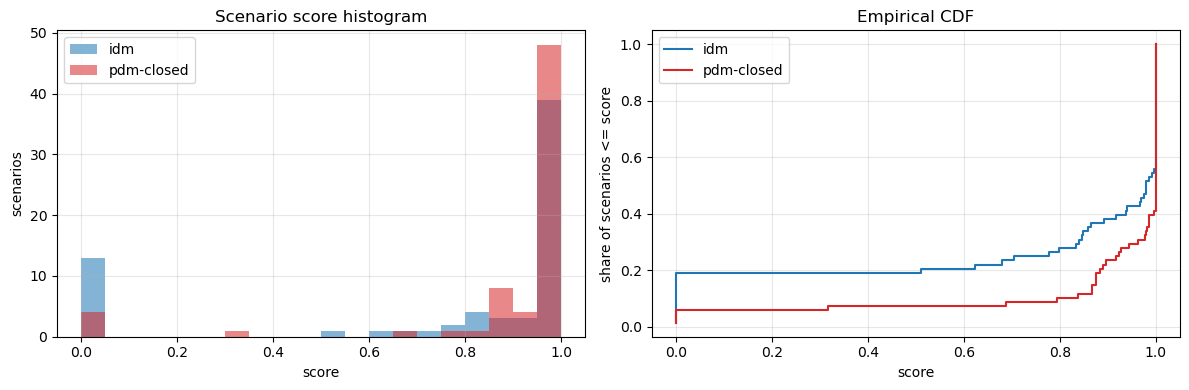

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bins = np.linspace(0, 1, 21)
for planner in PLANNERS:
    s = long.loc[long.planner == planner, "score"]
    axes[0].hist(s, bins=bins, alpha=0.55, label=planner, color=COLORS[planner])
    x = np.sort(s)
    axes[1].step(x, np.arange(1, len(x) + 1) / len(x), where="post", label=planner, color=COLORS[planner])
axes[0].set(title="Scenario score histogram", xlabel="score", ylabel="scenarios")
axes[1].set(title="Empirical CDF", xlabel="score", ylabel="share of scenarios <= score")
for ax in axes:
    ax.legend()
fig.tight_layout()
save(fig, "01_score_distribution")
plt.show()

The score is **bounded, zero-inflated and piled up near 1**. Any model or effect
estimate has to respect that shape (a mean hides a mix of "fine" and "failed" scenarios).

## 3. Component metrics: what drives the scores

In [6]:
component = pd.DataFrame({
    planner: {
        **{f"{m} (mean)": g[m].mean() for m in METRICS},
    }
    for planner, g in long.groupby("planner")
})
failure_rate = long.groupby("planner")[METRICS].agg(lambda s: (s < 1 - EPS).mean()).T
failure_rate.columns = [f"{c}: share < 1" for c in failure_rate.columns]
means = long.groupby("planner")[METRICS].mean().T
means.columns = [f"{c}: mean" for c in means.columns]
pd.concat([means, failure_rate], axis=1)

,idm: mean,pdm-closed: mean,idm: share < 1,pdm-closed: share < 1
no_ego_at_fault_collisions,0.904,0.985,0.103,0.015
drivable_area_compliance,0.868,0.971,0.132,0.029
driving_direction_compliance,0.993,1.000,0.015,0.000
ego_is_making_progress,0.971,0.985,0.029,0.015
ego_progress_along_expert_route,0.856,0.912,0.441,0.338
time_to_collision_within_bound,0.809,0.956,0.191,0.044
speed_limit_compliance,0.974,0.998,0.088,0.074
ego_is_comfortable,0.912,0.912,0.088,0.088


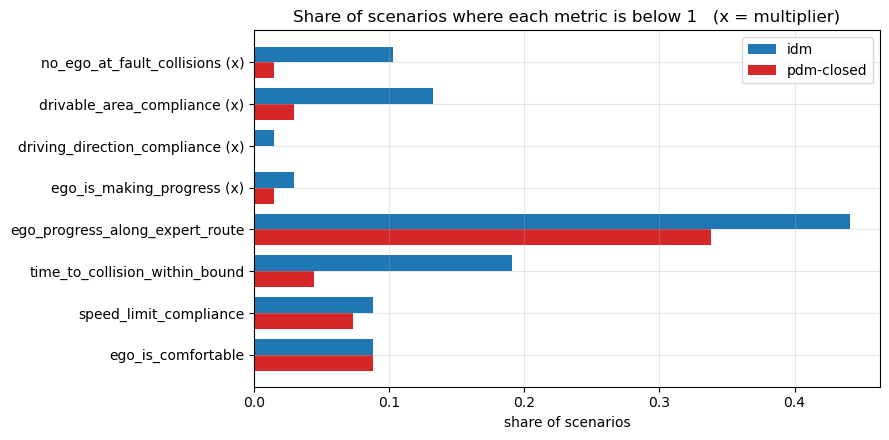

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
y = np.arange(len(METRICS))
for i, planner in enumerate(PLANNERS):
    ax.barh(y + (i - 0.5) * 0.38, failure_rate.iloc[:, i], height=0.38,
            label=planner, color=COLORS[planner])
ax.set_yticks(y, [f"{m}{' (x)' if m in MULTIPLIERS else ''}" for m in METRICS])
ax.invert_yaxis()
ax.set(title="Share of scenarios where each metric is below 1   (x = multiplier)", xlabel="share of scenarios")
ax.legend()
fig.tight_layout()
save(fig, "02_metric_failure_rates")
plt.show()

**Why are zero scores zero?** Each zero must have at least one multiplier at 0:

In [8]:
zeros = long[long["score"] <= EPS]
cause = zeros[MULTIPLIERS].le(EPS)
summary = cause.groupby(zeros["planner"]).sum()
summary["zero_scores"] = zeros.groupby("planner").size()
summary

,no_ego_at_fault_collisions,drivable_area_compliance,driving_direction_compliance,ego_is_making_progress,zero_scores
planner,,,,,
idm,6,9,0,2,13
pdm-closed,1,2,0,1,4


## 4. Matched pairs: PDM-Closed vs IDM on the same scenario

In [9]:
wide = long.pivot(index="scenario_id", columns="planner", values="score")
meta = long.drop_duplicates("scenario_id").set_index("scenario_id")[
    ["log_name", "scenario_type", "map_name", "city", "all_scenario_tags"]]
pairs = meta.join(wide)
pairs["delta"] = pairs["pdm-closed"] - pairs["idm"]
pairs["outcome"] = np.select([pairs.delta > EPS, pairs.delta < -EPS], ["pdm better", "idm better"], "tie")

counts = pairs["outcome"].value_counts().reindex(["pdm better", "tie", "idm better"], fill_value=0)
print(counts.to_string())
print(f"ties where both score 1.0: {((pairs.idm >= 1 - EPS) & (pairs['pdm-closed'] >= 1 - EPS)).sum()}")
print(f"mean delta {pairs.delta.mean():.4f} | median delta {pairs.delta.median():.4f}")

outcome
pdm better    33
tie           30
idm better     5
ties where both score 1.0: 28
mean delta 0.1403 | median delta 0.0000


**Uncertainty, accounting for logs.** Scenarios from the same log are not independent,
so the interval resamples whole logs (cluster bootstrap, 10,000 draws, seed 0). The
Wilcoxon signed-rank test treats scenarios as independent and is shown only for reference.

In [10]:
rng = np.random.default_rng(0)
by_log = pairs.groupby("log_name")["delta"].agg(["sum", "count"])
draws = rng.integers(0, len(by_log), size=(10_000, len(by_log)))
boot = by_log["sum"].to_numpy()[draws].sum(1) / by_log["count"].to_numpy()[draws].sum(1)
low, high = np.percentile(boot, [2.5, 97.5])
print(f"mean delta (pdm - idm) = {pairs.delta.mean():.3f}, log-cluster bootstrap 95% CI [{low:.3f}, {high:.3f}]")
print(f"share of bootstrap draws <= 0: {(boot <= 0).mean():.4f}")
nonzero = pairs.delta[pairs.delta.abs() > EPS]
print(f"Wilcoxon signed-rank on {len(nonzero)} non-tied pairs: p = {stats.wilcoxon(nonzero).pvalue:.2g} (ignores log clustering)")

mean delta (pdm - idm) = 0.140, log-cluster bootstrap 95% CI [0.050, 0.238]
share of bootstrap draws <= 0: 0.0011
Wilcoxon signed-rank on 38 non-tied pairs: p = 6.4e-05 (ignores log clustering)


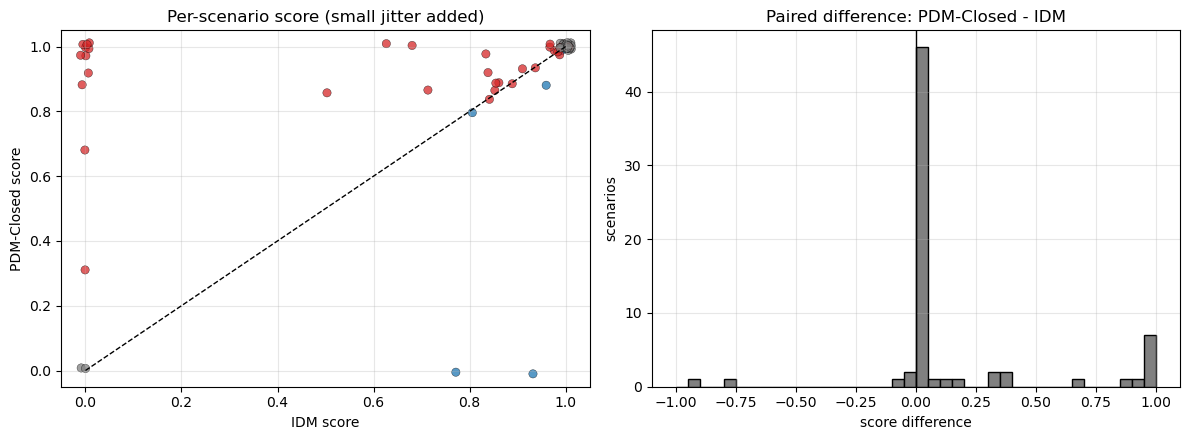

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = pairs["outcome"].map({"pdm better": COLORS["pdm-closed"], "idm better": COLORS["idm"], "tie": "grey"})
jitter = np.random.default_rng(1).uniform(-0.012, 0.012, size=(2, len(pairs)))
axes[0].scatter(pairs.idm + jitter[0], pairs["pdm-closed"] + jitter[1], c=colors, alpha=0.75, edgecolor="k", linewidth=0.3)
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set(title="Per-scenario score (small jitter added)", xlabel="IDM score", ylabel="PDM-Closed score",
            xlim=(-0.05, 1.05), ylim=(-0.05, 1.05))
axes[1].hist(pairs.delta, bins=np.linspace(-1, 1, 41), color="grey", edgecolor="k")
axes[1].axvline(0, color="k", lw=1)
axes[1].set(title="Paired difference: PDM-Closed - IDM", xlabel="score difference", ylabel="scenarios")
fig.tight_layout()
save(fig, "03_paired_scores")
plt.show()

**Zero-score transitions** (does one planner fail where the other succeeds?)

In [12]:
pd.crosstab(np.where(pairs.idm <= EPS, "IDM = 0", "IDM > 0"),
            np.where(pairs["pdm-closed"] <= EPS, "PDM = 0", "PDM > 0"))

col_0,PDM = 0,PDM > 0
row_0,,
IDM = 0,2,11
IDM > 0,2,53


**Where the total difference comes from:**

In [13]:
idm_zero_pdm_ok = (pairs.idm <= EPS) & (pairs["pdm-closed"] > EPS)
parts = pd.Series({
    "IDM = 0, PDM-Closed > 0": pairs.delta[idm_zero_pdm_ok].sum(),
    "other PDM-Closed gains": pairs.delta[~idm_zero_pdm_ok & (pairs.delta > EPS)].sum(),
    "PDM-Closed losses": pairs.delta[pairs.delta < -EPS].sum(),
})
pd.DataFrame({"pairs": [idm_zero_pdm_ok.sum(), (~idm_zero_pdm_ok & (pairs.delta > EPS)).sum(), (pairs.delta < -EPS).sum()],
              "sum_of_delta": parts, "share_of_net_total": parts / pairs.delta.sum()})

,pairs,sum_of_delta,share_of_net_total
"IDM = 0, PDM-Closed > 0",11,9.731,1.020
other PDM-Closed gains,22,1.640,0.172
PDM-Closed losses,5,-1.828,-0.192


**Largest differences**, with the components that differ between the two runs:

In [14]:
comp = long.set_index(["scenario_id", "planner"])[METRICS].unstack("planner")

def changed_metrics(sid):
    row = comp.loc[sid]
    diffs = {m: row[(m, "pdm-closed")] - row[(m, "idm")] for m in METRICS}
    return ", ".join(f"{m} {d:+.2f}" for m, d in sorted(diffs.items(), key=lambda kv: -abs(kv[1])) if abs(d) > 0.01)

top = pairs.reindex(pairs.delta.abs().sort_values(ascending=False).index).head(12).copy()
top["changed_components (pdm - idm)"] = [changed_metrics(sid) for sid in top.index]
top[["scenario_type", "city", "idm", "pdm-closed", "delta", "changed_components (pdm - idm)"]].reset_index(drop=True)

,scenario_type,city,idm,pdm-closed,delta,changed_components (pdm - idm)
0,low_magnitude_speed,Singapore,0.000,1.000,1.000,"drivable_area_compliance +1.00, time_to_collision_within_bound +1.00, ego_is_comfortable +1.00"
1,starting_right_turn,Boston,0.000,1.000,1.000,drivable_area_compliance +1.00
2,stopping_with_lead,Boston,0.000,1.000,1.000,"drivable_area_compliance +1.00, ego_is_making_progress +1.00, time_to_collision_within_bound +1.00, ego_is..."
3,high_magnitude_speed,Las Vegas,0.000,1.000,1.000,"no_ego_at_fault_collisions +1.00, time_to_collision_within_bound +1.00"
4,changing_lane,Pittsburgh,0.000,0.985,0.985,"drivable_area_compliance +1.00, ego_progress_along_expert_route -0.02"
5,starting_right_turn,Pittsburgh,0.000,0.976,0.976,"drivable_area_compliance +1.00, ego_progress_along_expert_route +0.18"
6,changing_lane,Las Vegas,0.000,0.962,0.962,"drivable_area_compliance +1.00, ego_is_making_progress +1.00, time_to_collision_within_bound +1.00, ego_is..."
7,traversing_pickup_dropoff,Las Vegas,0.938,0.000,-0.938,"drivable_area_compliance -1.00, speed_limit_compliance +0.21, ego_progress_along_expert_route -0.02"
8,waiting_for_pedestrian_to_cross,Las Vegas,0.000,0.927,0.927,"no_ego_at_fault_collisions +1.00, drivable_area_compliance +1.00, time_to_collision_within_bound +1.00, eg..."
9,waiting_for_pedestrian_to_cross,Singapore,0.000,0.875,0.875,"no_ego_at_fault_collisions +1.00, time_to_collision_within_bound +1.00, ego_is_comfortable -1.00"


## 5. By challenge category

At most five scenarios per category, so these are descriptions of this sample, not
category-level estimates.

In [15]:
def group_table(key):
    g = pairs.groupby(key)
    table = pd.DataFrame({
        "n": g.size(),
        "idm_mean": g["idm"].mean(),
        "pdm_mean": g["pdm-closed"].mean(),
        "mean_delta": g["delta"].mean(),
        "pdm_better": g["outcome"].apply(lambda s: (s == "pdm better").sum()),
        "idm_better": g["outcome"].apply(lambda s: (s == "idm better").sum()),
        "ties": g["outcome"].apply(lambda s: (s == "tie").sum()),
        "idm_zero": g["idm"].apply(lambda s: (s <= EPS).sum()),
        "pdm_zero": g["pdm-closed"].apply(lambda s: (s <= EPS).sum()),
    })
    return table.sort_values("mean_delta", ascending=False)

by_type = group_table("scenario_type")
by_type

,n,idm_mean,pdm_mean,mean_delta,pdm_better,idm_better,ties,idm_zero,pdm_zero
scenario_type,,,,,,,,,
waiting_for_pedestrian_to_cross,4,0.441,0.911,0.470,4,0,0,2,0
changing_lane,5,0.568,0.983,0.415,3,1,1,2,0
low_magnitude_speed,5,0.535,0.937,0.402,4,0,1,2,0
starting_right_turn,5,0.594,0.995,0.401,3,0,2,2,0
high_magnitude_speed,5,0.725,1.000,0.275,2,0,3,1,0
stopping_with_lead,5,0.800,1.000,0.200,1,0,4,1,0
near_multiple_vehicles,5,0.600,0.664,0.064,1,0,4,2,1
high_lateral_acceleration,5,0.909,0.953,0.044,3,0,2,0,0
following_lane_with_lead,4,0.926,0.933,0.007,3,0,1,0,0


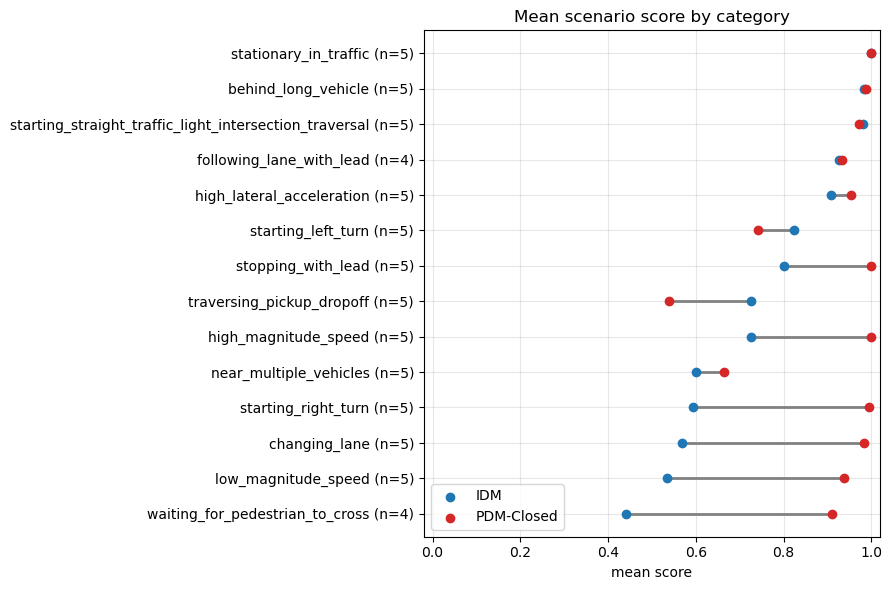

In [16]:
order = by_type.sort_values("idm_mean").index
fig, ax = plt.subplots(figsize=(9, 6))
y = np.arange(len(order))
ax.hlines(y, by_type.loc[order, "idm_mean"], by_type.loc[order, "pdm_mean"], color="grey", lw=2)
ax.scatter(by_type.loc[order, "idm_mean"], y, color=COLORS["idm"], label="IDM", zorder=3)
ax.scatter(by_type.loc[order, "pdm_mean"], y, color=COLORS["pdm-closed"], label="PDM-Closed", zorder=3)
ax.set_yticks(y, [f"{t} (n={by_type.loc[t, 'n']})" for t in order])
ax.set(title="Mean scenario score by category", xlabel="mean score", xlim=(-0.02, 1.02))
ax.legend(loc="lower left")
fig.tight_layout()
save(fig, "04_category_means")
plt.show()

## 6. By map / city

In [17]:
group_table("city")

,n,idm_mean,pdm_mean,mean_delta,pdm_better,idm_better,ties,idm_zero,pdm_zero
city,,,,,,,,,
Singapore,2,0.000,0.938,0.938,2,0,0,2,0
Boston,7,0.672,0.982,0.310,3,0,4,2,0
Pittsburgh,7,0.489,0.701,0.213,5,2,0,3,1
Las Vegas,52,0.838,0.915,0.077,23,3,26,6,3


## 7. Log structure

Most logs contribute one or two scenarios. If scenarios from the same log behave alike,
log-grouped splits and log-clustered uncertainty are necessary. A permutation test
compares the within-log spread of the paired difference with random groupings of the
same sizes (logs with at least two scenarios only).

In [18]:
per_log = pairs.groupby("log_name").size()
print("scenarios per log -> number of logs:", per_log.value_counts().sort_index().to_dict())

multi = pairs[pairs.log_name.map(per_log) >= 2]
def within_log_var(values, groups):
    return pd.Series(values).groupby(groups).var(ddof=0).mean()

observed = within_log_var(multi.delta.to_numpy(), multi.log_name.to_numpy())
rng = np.random.default_rng(0)
null = np.array([within_log_var(rng.permutation(multi.delta.to_numpy()), multi.log_name.to_numpy())
                 for _ in range(5_000)])
print(f"{multi.log_name.nunique()} logs with >= 2 scenarios ({len(multi)} scenarios)")
print(f"mean within-log variance of delta: observed {observed:.4f} vs permuted mean {null.mean():.4f}")
print(f"permutation p (observed <= permuted): {(null <= observed).mean():.3f}")

scenarios per log -> number of logs: {1: 16, 2: 15, 3: 6, 4: 1}


22 logs with >= 2 scenarios (52 scenarios)
mean within-log variance of delta: observed 0.0857 vs permuted mean 0.0941
permutation p (observed <= permuted): 0.300


## 8. Scenario tags (descriptive only)

`all_scenario_tags` lists every nuPlan tag at the anchor. Tags are assigned 3 s after
simulation start and describe the logged driver's behavior, so they are **not** model
inputs; this only shows which situations coincide with large differences. Tags on
fewer than 5 scenarios are omitted.

In [19]:
tags = pairs.assign(tag=pairs.all_scenario_tags.str.split("|")).explode("tag")
tag_table = tags.groupby("tag").agg(
    n=("delta", "size"), idm_mean=("idm", "mean"), pdm_mean=("pdm-closed", "mean"),
    mean_delta=("delta", "mean"), idm_zero=("idm", lambda s: (s <= EPS).sum()))
print("scenarios with more than one tag:", (pairs.all_scenario_tags.str.count(r"\|") > 0).sum())
tag_table[tag_table.n >= 5].sort_values("mean_delta", ascending=False)

scenarios with more than one tag: 49


,n,idm_mean,pdm_mean,mean_delta,idm_zero
tag,,,,,
changing_lane,5,0.568,0.983,0.415,2
low_magnitude_speed,5,0.535,0.937,0.402,2
starting_right_turn,5,0.594,0.995,0.401,2
high_magnitude_speed,5,0.725,1.000,0.275,1
stopping_with_lead,5,0.800,1.000,0.200,1
on_traffic_light_intersection,14,0.792,0.964,0.172,2
stationary,14,0.823,0.970,0.147,2
on_intersection,21,0.748,0.873,0.126,4
traversing_traffic_light_intersection,13,0.853,0.967,0.114,1


## 9. Takeaways

Descriptive findings for this 68-scenario sample (numbers from the cells above):

1. **PDM-Closed scores higher on the same scenarios.** Mean 0.900 vs 0.760; the mean
   paired difference is +0.140 with a log-cluster bootstrap 95% CI of about
   [0.05, 0.24]. Pairs: 33 PDM-Closed better, 30 ties (28 with both at 1.0),
   5 IDM better.
2. **The advantage is concentrated in a few failures.** The 11 scenarios where IDM
   scores 0 and PDM-Closed does not account for roughly all of the net difference;
   the remaining gains (+1.64 summed) and PDM-Closed's losses (-1.83) about cancel.
   The planner effect is mostly "does the planner avoid a failure gate", not a
   uniform shift.
3. **Zeros come from multiplier gates.** IDM's 13 zero scores involve drivable-area
   violations (9), at-fault collisions (6) and lack of progress (2), with overlap;
   PDM-Closed has 4 zeros. Time-to-collision violations drop from 19% (IDM) to 4%;
   comfort is identical (8.8% for both).
4. **Heterogeneity by category (descriptive, n <= 5 each).** Large gains in
   `waiting_for_pedestrian_to_cross`, `changing_lane`, `low_magnitude_speed` and
   `starting_right_turn`; PDM-Closed is worse in `traversing_pickup_dropoff`
   (2 PDM-Closed zeros) and `starting_left_turn`; `stationary_in_traffic` is all ties at 1.
5. **Maps are confounded with logs.** Singapore is 2 scenarios from a single log, both
   IDM zeros; Las Vegas (52 scenarios) shows the smallest mean gain.
6. **No detectable within-log similarity** of the paired difference (permutation
   p = 0.30), but with 22 multi-scenario logs the test has little power. Log-grouped
   splits remain the rule.

Implications for the first model (not trained here):

- The outcome is bounded, zero-inflated and capped at 1, and the paired difference is
  exactly 0 for 30 of 68 scenarios. A two-part view (probability that a failure gate
  fires, then the score given no failure) fits the data better than a plain mean model.
- Most of the information about *where* the planners differ sits in about 15 scenarios
  in which at least one planner scores 0, so heterogeneity estimates will be noisy;
  expanding the subset is the main lever.
- Category labels are look-ahead; explaining which scenarios trip IDM's gates needs the
  pre-simulation features (ego speed, agents, lane/intersection context) that are not
  extracted yet.